In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import warnings

warnings.filterwarnings("ignore")

In [4]:
# ============================================================
# SETUP — adjust these paths to match your folder structure
# ============================================================

DATA_PATH = r"..\..\Data\Main\modelling_dataset.csv"

OUTPUT_DIR = r"..\..\Dissertation_Results"
TABLES_DIR = os.path.join(OUTPUT_DIR, "Tables")
FIGURES_DIR = os.path.join(OUTPUT_DIR, "Figures")

os.makedirs(TABLES_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

In [5]:
# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(DATA_PATH)

df['date'] = pd.to_datetime(df['date'])

model_df = df.dropna(subset=['volatility_20d', 'next_day_return']).copy()

model_df = model_df.sort_values(['ticker', 'date']).reset_index(drop=True)

features = ['sentiment', 'volatility_20d', 'sent_x_vol']

print(f"Dataset: {model_df.shape[0]:,} rows, {model_df['ticker'].nunique()} tickers")
print(f"Date range: {model_df['date'].min().date()} to {model_df['date'].max().date()}")

Dataset: 578,903 rows, 523 tickers
Date range: 2020-01-31 to 2025-12-30


In [6]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def sig_stars(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.1:
        return "*"
    else:
        return "ns"


def run_logit(data):
    """
    Run logistic regression and return the fitted model.
    """
    X = sm.add_constant(data[features])
    y = data['target']
    
    result = sm.Logit(y, X).fit(disp=0)
    
    return result


def get_window_data(start, end):
    """
    Filter model_df to a date range and drop rows with missing feature values.
    """
    return model_df[
        (model_df['date'] >= start) &
        (model_df['date'] <= end)
    ].dropna(subset=features)

In [7]:
# ============================================================
# WINDOW CONFIGURATIONS
# ============================================================

window_configs = {
    '1-year': [
        ('2020', '2020-01-01', '2020-12-31'),
        ('2021', '2021-01-01', '2021-12-31'),
        ('2022', '2022-01-01', '2022-12-31'),
        ('2023', '2023-01-01', '2023-12-31'),
        ('2024', '2024-01-01', '2024-12-31'),
        ('2025', '2025-01-01', '2025-12-31'),
    ],
    '2-year': [
        ('2020-2021', '2020-01-01', '2021-12-31'),
        ('2022-2023', '2022-01-01', '2023-12-31'),
        ('2024-2025', '2024-01-01', '2025-12-31'),
    ],
    '3-year': [
        ('2020-2022', '2020-01-01', '2022-12-31'),
        ('2023-2025', '2023-01-01', '2025-12-31'),
    ],
}

In [8]:
# ============================================================
# TABLE 1 — Regime Balance Comparison
# ============================================================

print("=" * 80)
print("TABLE 1: Regime Balance Comparison Across Window Configurations")
print("=" * 80)

table1_rows = []

for config_name, windows in window_configs.items():
    for name, start, end in windows:
        subset = get_window_data(start, end)
        
        vol_pct = (subset['volatile_market'] == 1).mean() * 100
        
        table1_rows.append({
            'Config': config_name,
            'Window': name,
            'N': len(subset),
            'Volatile %': round(vol_pct, 1),
            'Calm %': round(100 - vol_pct, 1),
            'Independent Tests': len(windows)
        })

table1 = pd.DataFrame(table1_rows)

display(table1)

table1.to_csv(
    os.path.join(TABLES_DIR, "Table1_Regime_Balance.csv"),
    index=False
)

print("Saved: Table1_Regime_Balance.csv")

TABLE 1: Regime Balance Comparison Across Window Configurations


,Config,Window,N,Volatile %,Calm %,Independent Tests
0,1-year,2020,74636,93.9,6.1,6
1,1-year,2021,90514,35.4,64.6,6
2,1-year,2022,105455,84.6,15.4,6
3,1-year,2023,104574,18.3,81.7,6
4,1-year,2024,105073,18.1,81.9,6
5,1-year,2025,98651,61.4,38.6,6
6,2-year,2020-2021,165150,61.9,38.1,3
7,2-year,2022-2023,210029,51.6,48.4,3
8,2-year,2024-2025,203724,39.1,60.9,3
9,3-year,2020-2022,270605,70.7,29.3,2


Saved: Table1_Regime_Balance.csv


In [9]:
# ============================================================
# TABLE 2 — Non-Overlapping 2-Year Windows
# ============================================================

print("=" * 80)
print("TABLE 2: Non-Overlapping 2-Year Window Results")
print("=" * 80)

non_overlap_windows = [
    ('2020-2021', '2020-01-01', '2021-12-31'),
    ('2022-2023', '2022-01-01', '2023-12-31'),
    ('2024-2025', '2024-01-01', '2025-12-31'),
]

table2_rows = []

for name, start, end in non_overlap_windows:
    subset = get_window_data(start, end)
    r = run_logit(subset)
    
    table2_rows.append({
        'Window': name,
        'N': len(subset),
        'Sent coef': round(r.params['sentiment'], 4),
        'Sent p': round(r.pvalues['sentiment'], 4),
        'Sent sig': sig_stars(r.pvalues['sentiment']),
        'Vol coef': round(r.params['volatility_20d'], 4),
        'Vol p': round(r.pvalues['volatility_20d'], 4),
        'Vol sig': sig_stars(r.pvalues['volatility_20d']),
        'Interact coef': round(r.params['sent_x_vol'], 4),
        'Interact p': round(r.pvalues['sent_x_vol'], 4),
        'Interact sig': sig_stars(r.pvalues['sent_x_vol']),
    })

table2 = pd.DataFrame(table2_rows)

display(table2)

table2.to_csv(
    os.path.join(TABLES_DIR, "Table2_NonOverlap_Results.csv"),
    index=False
)

print("Saved: Table2_NonOverlap_Results.csv")

TABLE 2: Non-Overlapping 2-Year Window Results


,Window,N,Sent coef,Sent p,Sent sig,Vol coef,Vol p,Vol sig,Interact coef,Interact p,Interact sig
0,2020-2021,165150,-0.0347,0.2003,ns,-0.6322,0.0194,**,2.4098,0.0063,***
1,2022-2023,210029,0.0175,0.5129,ns,0.1761,0.7017,ns,-3.7714,0.0011,***
2,2024-2025,203724,-0.1660,0.0000,***,0.7172,0.1023,ns,6.5711,0.0001,***


Saved: Table2_NonOverlap_Results.csv


In [10]:
# ============================================================
# TABLE 3 — Overlapping 2-Year Windows
# ============================================================

print("=" * 80)
print("TABLE 3: Overlapping 2-Year Window Results")
print("=" * 80)

overlap_windows = [
    ('2020-2021', '2020-01-01', '2021-12-31'),
    ('2021-2022', '2021-01-01', '2022-12-31'),
    ('2022-2023', '2022-01-01', '2023-12-31'),
    ('2023-2024', '2023-01-01', '2024-12-31'),
    ('2024-2025', '2024-01-01', '2025-12-31'),
]

table3_rows = []

for name, start, end in overlap_windows:
    subset = get_window_data(start, end)
    r = run_logit(subset)
    
    table3_rows.append({
        'Window': name,
        'N': len(subset),
        'Interact coef': round(r.params['sent_x_vol'], 4),
        'Interact p': round(r.pvalues['sent_x_vol'], 4),
        'Significance': sig_stars(r.pvalues['sent_x_vol']),
        'Direction': 'Positive' if r.params['sent_x_vol'] > 0 else 'Negative',
    })

table3 = pd.DataFrame(table3_rows)

display(table3)

table3.to_csv(
    os.path.join(TABLES_DIR, "Table3_Overlap_Results.csv"),
    index=False
)

print("Saved: Table3_Overlap_Results.csv")

TABLE 3: Overlapping 2-Year Window Results


,Window,N,Interact coef,Interact p,Significance,Direction
0,2020-2021,165150,2.4098,0.0063,***,Positive
1,2021-2022,195969,-2.8847,0.0164,**,Negative
2,2022-2023,210029,-3.7714,0.0011,***,Negative
3,2023-2024,209647,3.1157,0.0495,**,Positive
4,2024-2025,203724,6.5711,0.0001,***,Positive


Saved: Table3_Overlap_Results.csv


In [11]:
# ============================================================
# FULL PERIOD RESULT
# ============================================================

print("=" * 80)
print("FULL PERIOD: Interaction Term")
print("=" * 80)

full_data = model_df.dropna(subset=features)

r_full = run_logit(full_data)

print(f"N = {len(full_data):,}")
print(f"Sentiment:   coef={r_full.params['sentiment']:.4f}, p={r_full.pvalues['sentiment']:.4f} {sig_stars(r_full.pvalues['sentiment'])}")
print(f"Volatility:  coef={r_full.params['volatility_20d']:.4f}, p={r_full.pvalues['volatility_20d']:.4f} {sig_stars(r_full.pvalues['volatility_20d'])}")
print(f"Interaction: coef={r_full.params['sent_x_vol']:.4f}, p={r_full.pvalues['sent_x_vol']:.4f} {sig_stars(r_full.pvalues['sent_x_vol'])}")

FULL PERIOD: Interaction Term
N = 578,903
Sentiment:   coef=-0.0571, p=0.0004 ***
Volatility:  coef=0.1003, p=0.6170 ns
Interaction: coef=1.3595, p=0.0321 **


In [12]:
# ============================================================
# TABLE 5a — Robustness: Volatility Threshold Sensitivity
# ============================================================

print("=" * 80)
print("TABLE 5a: Robustness — Volatility Threshold Sensitivity")
print("=" * 80)

quantiles = [0.25, 0.50, 0.75]

table5a_rows = []

for q in quantiles:
    cutoff = model_df['market_vol'].quantile(q)
    
    vol_data = model_df[
        model_df['market_vol'] > cutoff
    ].dropna(subset=features)
    
    calm_data = model_df[
        model_df['market_vol'] <= cutoff
    ].dropna(subset=features)
    
    r_vol = run_logit(vol_data)
    r_calm = run_logit(calm_data)
    
    table5a_rows.append({
        'Threshold': f"{int(q * 100)}th percentile",
        'Cutoff': round(cutoff, 4),
        'Volatile N': len(vol_data),
        'Volatile Interact p': round(r_vol.pvalues['sent_x_vol'], 4),
        'Volatile sig': sig_stars(r_vol.pvalues['sent_x_vol']),
        'Calm N': len(calm_data),
        'Calm Interact p': round(r_calm.pvalues['sent_x_vol'], 4),
        'Calm sig': sig_stars(r_calm.pvalues['sent_x_vol']),
    })

table5a = pd.DataFrame(table5a_rows)

display(table5a)

table5a.to_csv(
    os.path.join(TABLES_DIR, "Table5a_Threshold_Sensitivity.csv"),
    index=False
)

print("Saved: Table5a_Threshold_Sensitivity.csv")

TABLE 5a: Robustness — Volatility Threshold Sensitivity


,Threshold,Cutoff,Volatile N,Volatile Interact p,Volatile sig,Calm N,Calm Interact p,Calm sig
0,25th percentile,0.0171,433904,0.0076,***,144999,0.8836,ns
1,50th percentile,0.0192,289192,0.0057,***,289711,0.3173,ns
2,75th percentile,0.0225,144503,0.0003,***,434400,0.5572,ns


Saved: Table5a_Threshold_Sensitivity.csv


In [13]:
# ============================================================
# TABLE 5b — Robustness: Zero-Sentiment Exclusion
# ============================================================

print("=" * 80)
print("TABLE 5b: Robustness — Zero-Sentiment Exclusion")
print("=" * 80)

nonzero_data = model_df[
    model_df['sentiment'] != 0
].dropna(subset=features)

table5b_rows = []

for name, start, end in non_overlap_windows:
    with_z = full_data[
        (full_data['date'] >= start) &
        (full_data['date'] <= end)
    ]
    
    without_z = nonzero_data[
        (nonzero_data['date'] >= start) &
        (nonzero_data['date'] <= end)
    ]
    
    r_wz = run_logit(with_z)
    r_woz = run_logit(without_z)
    
    table5b_rows.append({
        'Window': name,
        'With zeros N': len(with_z),
        'With zeros Interact p': round(r_wz.pvalues['sent_x_vol'], 4),
        'With zeros sig': sig_stars(r_wz.pvalues['sent_x_vol']),
        'Without zeros N': len(without_z),
        'Without zeros Interact p': round(r_woz.pvalues['sent_x_vol'], 4),
        'Without zeros sig': sig_stars(r_woz.pvalues['sent_x_vol']),
    })

table5b = pd.DataFrame(table5b_rows)

display(table5b)

table5b.to_csv(
    os.path.join(TABLES_DIR, "Table5b_Zero_Sentiment.csv"),
    index=False
)

print("Saved: Table5b_Zero_Sentiment.csv")

TABLE 5b: Robustness — Zero-Sentiment Exclusion


,Window,With zeros N,With zeros Interact p,With zeros sig,Without zeros N,Without zeros Interact p,Without zeros sig
0,2020-2021,165150,0.0063,***,93292,0.0075,***
1,2022-2023,210029,0.0011,***,185242,0.0004,***
2,2024-2025,203724,0.0001,***,160822,0.0000,***


Saved: Table5b_Zero_Sentiment.csv


In [14]:
# ============================================================
# TABLE 5c — Robustness: Per-Stock vs Market-Wide Volatility
# ============================================================

print("=" * 80)
print("TABLE 5c: Robustness — Per-Stock vs Market-Wide Volatility")
print("=" * 80)

model_df_copy = model_df.copy()

model_df_copy['stock_vol_median'] = model_df_copy.groupby('ticker')['volatility_20d'].transform('median')

model_df_copy['stock_volatile'] = (
    model_df_copy['volatility_20d'] > model_df_copy['stock_vol_median']
).astype(int)

vol_tests = [
    (
        'Stock-level volatile',
        model_df_copy[model_df_copy['stock_volatile'] == 1].dropna(subset=features)
    ),
    (
        'Stock-level calm',
        model_df_copy[model_df_copy['stock_volatile'] == 0].dropna(subset=features)
    ),
    (
        'Market-wide volatile',
        model_df[model_df['volatile_market'] == 1].dropna(subset=features)
    ),
    (
        'Market-wide calm',
        model_df[model_df['volatile_market'] == 0].dropna(subset=features)
    ),
]

table5c_rows = []

for name, data in vol_tests:
    r = run_logit(data)
    
    table5c_rows.append({
        'Regime': name,
        'N': len(data),
        'Interact coef': round(r.params['sent_x_vol'], 4),
        'Interact p': round(r.pvalues['sent_x_vol'], 4),
        'Significance': sig_stars(r.pvalues['sent_x_vol']),
    })

table5c = pd.DataFrame(table5c_rows)

display(table5c)

table5c.to_csv(
    os.path.join(TABLES_DIR, "Table5c_Volatility_Definition.csv"),
    index=False
)

print("Saved: Table5c_Volatility_Definition.csv")

TABLE 5c: Robustness — Per-Stock vs Market-Wide Volatility


,Regime,N,Interact coef,Interact p,Significance
0,Stock-level volatile,289328,2.3358,0.0020,***
1,Stock-level calm,289575,1.6576,0.5040,ns
2,Market-wide volatile,290175,2.1177,0.0044,***
3,Market-wide calm,288728,1.7985,0.2278,ns


Saved: Table5c_Volatility_Definition.csv


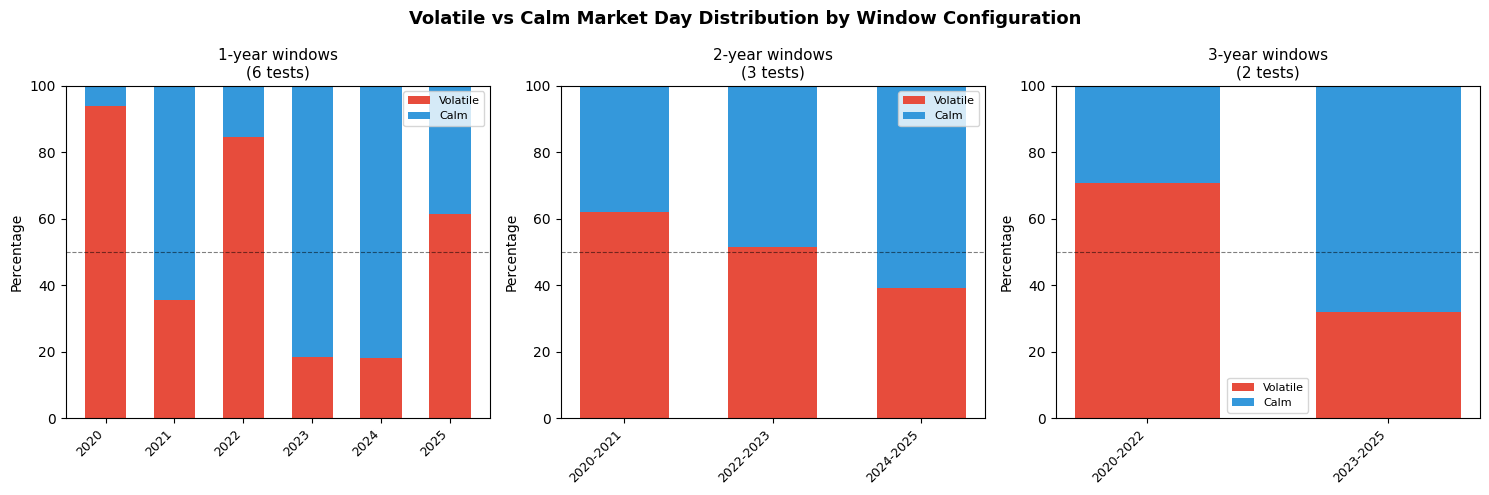

Saved: Fig1_Regime_Balance.png


In [15]:
# ============================================================
# FIGURE 1 — Regime Balance Visual
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

fig.suptitle(
    'Volatile vs Calm Market Day Distribution by Window Configuration',
    fontsize=13,
    fontweight='bold'
)

for ax, (config_name, windows) in zip(axes, window_configs.items()):
    names = [w[0] for w in windows]
    subset_data = [get_window_data(w[1], w[2]) for w in windows]
    
    vol_pcts = [(s['volatile_market'] == 1).mean() * 100 for s in subset_data]
    calm_pcts = [100 - v for v in vol_pcts]
    
    x = np.arange(len(names))
    
    ax.bar(x, vol_pcts, color='#e74c3c', label='Volatile', width=0.6)
    ax.bar(x, calm_pcts, bottom=vol_pcts, color='#3498db', label='Calm', width=0.6)
    
    ax.axhline(y=50, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
    
    ax.set_ylabel('Percentage')
    ax.set_title(f'{config_name} windows\n({len(windows)} tests)', fontsize=11)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=8)

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURES_DIR, "Fig1_Regime_Balance.png"),
    dpi=200,
    bbox_inches='tight'
)

plt.show()

print("Saved: Fig1_Regime_Balance.png")

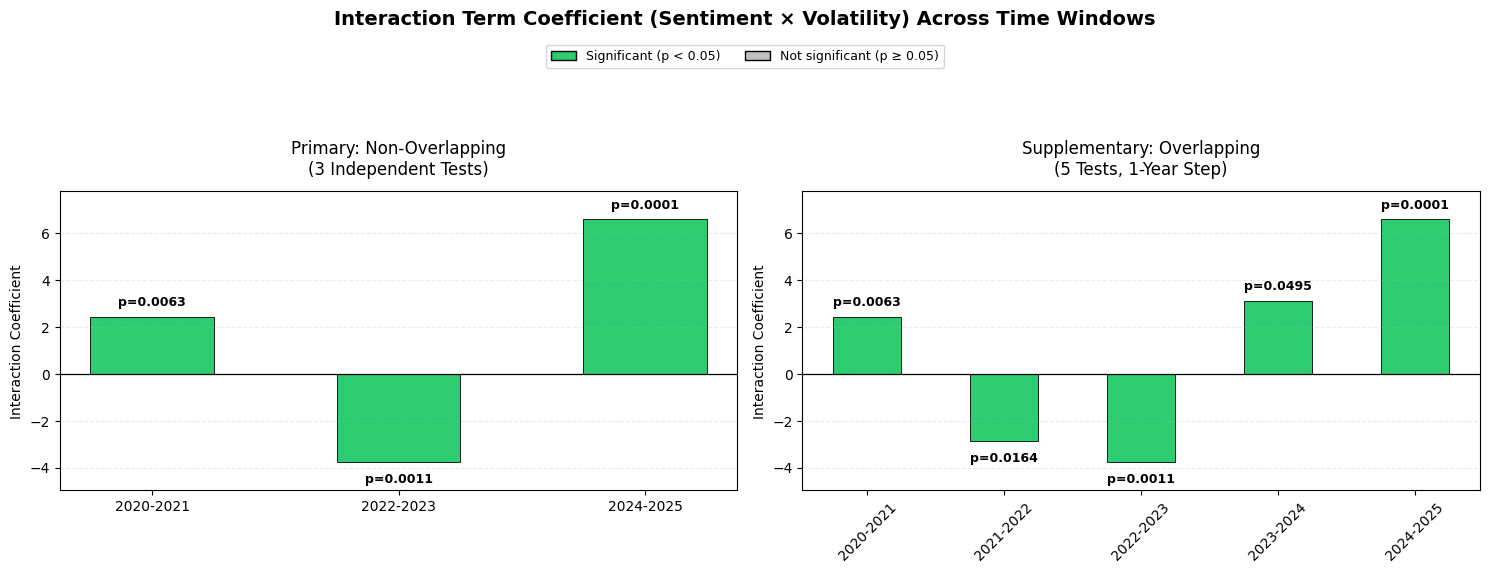

Saved: Fig2_Interaction_Coefficients.png


In [21]:
# ============================================================
# FIGURE 2 — Interaction Coefficients
# Color = significance, Direction = coefficient sign
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

# Main title
fig.suptitle(
    'Interaction Term Coefficient (Sentiment × Volatility) Across Time Windows',
    fontsize=14,
    fontweight='bold',
    y=0.98
)

# Legend for significance
legend_items = [
    mpatches.Patch(facecolor='#2ecc71', edgecolor='black', label='Significant (p < 0.05)'),
    mpatches.Patch(facecolor='#bfbfbf', edgecolor='black', label='Not significant (p ≥ 0.05)')
]

fig.legend(
    handles=legend_items,
    loc='upper center',
    ncol=2,
    fontsize=9,
    bbox_to_anchor=(0.5, 0.93),
    frameon=True
)

# ------------------------------------------------------------
# Non-overlapping windows
# ------------------------------------------------------------
coefs_no = [r['Interact coef'] for _, r in table2.iterrows()]
pvals_no = [r['Interact p'] for _, r in table2.iterrows()]

# Green if significant, grey otherwise
colors_no = ['#2ecc71' if p < 0.05 else '#bfbfbf' for p in pvals_no]

axes[0].bar(
    table2['Window'],
    coefs_no,
    color=colors_no,
    edgecolor='black',
    linewidth=0.6,
    width=0.5
)

axes[0].axhline(y=0, color='black', linewidth=0.9)
axes[0].set_ylabel('Interaction Coefficient')
axes[0].set_title('Primary: Non-Overlapping\n(3 Independent Tests)', fontsize=12, pad=12)

for i, (c, p) in enumerate(zip(coefs_no, pvals_no)):
    y_pos = c + 0.35 if c > 0 else c - 0.45
    va = 'bottom' if c > 0 else 'top'
    
    axes[0].text(
        i,
        y_pos,
        f'p={p:.4f}',
        ha='center',
        va=va,
        fontsize=9,
        fontweight='bold'
    )

# ------------------------------------------------------------
# Overlapping windows
# ------------------------------------------------------------
coefs_o = [r['Interact coef'] for _, r in table3.iterrows()]
pvals_o = [r['Interact p'] for _, r in table3.iterrows()]

# Green if significant, grey otherwise
colors_o = ['#2ecc71' if p < 0.05 else '#bfbfbf' for p in pvals_o]

axes[1].bar(
    table3['Window'],
    coefs_o,
    color=colors_o,
    edgecolor='black',
    linewidth=0.6,
    width=0.5
)

axes[1].axhline(y=0, color='black', linewidth=0.9)
axes[1].set_ylabel('Interaction Coefficient')
axes[1].set_title('Supplementary: Overlapping\n(5 Tests, 1-Year Step)', fontsize=12, pad=12)
axes[1].tick_params(axis='x', rotation=45)

for i, (c, p) in enumerate(zip(coefs_o, pvals_o)):
    y_pos = c + 0.35 if c > 0 else c - 0.45
    va = 'bottom' if c > 0 else 'top'
    
    axes[1].text(
        i,
        y_pos,
        f'p={p:.4f}',
        ha='center',
        va=va,
        fontsize=9,
        fontweight='bold'
    )

# ------------------------------------------------------------
# Dynamic y-axis limits
# ------------------------------------------------------------
all_coefs = coefs_no + coefs_o
y_min = min(all_coefs) - 1.2
y_max = max(all_coefs) + 1.2

for ax in axes:
    ax.set_ylim(y_min, y_max)
    ax.grid(axis='y', linestyle='--', alpha=0.25)

plt.tight_layout(rect=[0, 0, 1, 0.84])

plt.savefig(
    os.path.join(FIGURES_DIR, "Fig2_Interaction_Coefficients.png"),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Saved: Fig2_Interaction_Coefficients.png")

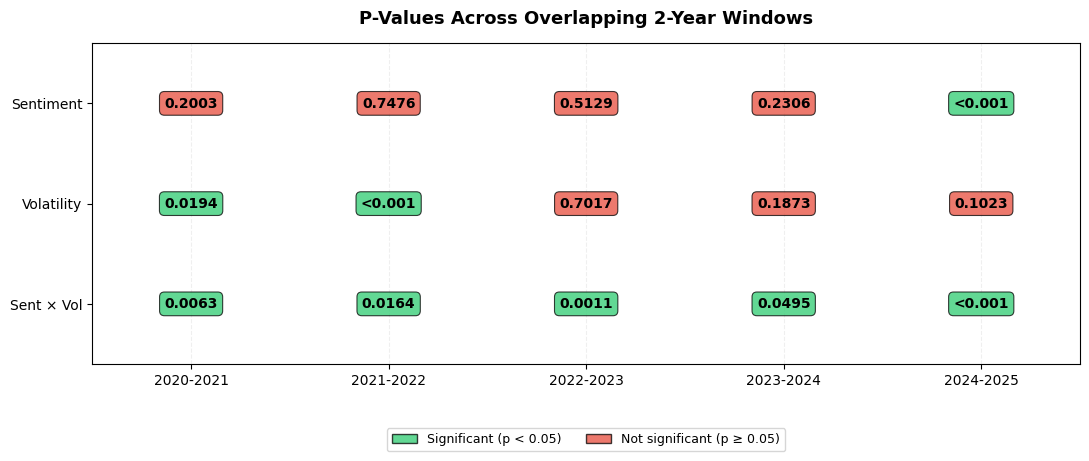

Saved: Fig3_PValue_Comparison.png


In [22]:
# ============================================================
# FIGURE 3 — P-Value Comparison Across Overlapping Windows
# Fixed version: no legend overlap, cleaner layout
# ============================================================

fig, ax = plt.subplots(figsize=(11, 4.8))

var_labels = ['Sentiment', 'Volatility', 'Sent × Vol']
var_keys = ['sentiment', 'volatility_20d', 'sent_x_vol']
y_positions = [2, 1, 0]

window_names = [name for name, _, _ in overlap_windows]

# ------------------------------------------------------------
# Plot p-value boxes
# ------------------------------------------------------------
for y_pos, var_key in zip(y_positions, var_keys):
    for i, (name, start, end) in enumerate(overlap_windows):
        subset = get_window_data(start, end)
        r = run_logit(subset)
        p = r.pvalues[var_key]

        box_color = '#2ecc71' if p < 0.05 else '#e74c3c'
        p_label = f'{p:.4f}' if p >= 0.001 else '<0.001'

        ax.text(
            i,
            y_pos,
            p_label,
            ha='center',
            va='center',
            fontsize=10,
            fontweight='bold',
            bbox=dict(
                boxstyle='round,pad=0.35',
                facecolor=box_color,
                edgecolor='black',
                linewidth=0.8,
                alpha=0.75
            )
        )

# ------------------------------------------------------------
# Axis formatting
# ------------------------------------------------------------
ax.set_yticks(y_positions)
ax.set_yticklabels(var_labels)

ax.set_xticks(range(len(window_names)))
ax.set_xticklabels(window_names, fontsize=10)

ax.set_xlim(-0.5, len(window_names) - 0.5)
ax.set_ylim(-0.6, 2.6)

ax.set_title(
    'P-Values Across Overlapping 2-Year Windows',
    fontsize=13,
    fontweight='bold',
    pad=14
)

ax.grid(axis='x', linestyle='--', alpha=0.2)

# ------------------------------------------------------------
# Legend outside the plot
# ------------------------------------------------------------
legend_items = [
    mpatches.Patch(facecolor='#2ecc71', edgecolor='black', alpha=0.75, label='Significant (p < 0.05)'),
    mpatches.Patch(facecolor='#e74c3c', edgecolor='black', alpha=0.75, label='Not significant (p ≥ 0.05)')
]

ax.legend(
    handles=legend_items,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    fontsize=9,
    frameon=True
)

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURES_DIR, "Fig3_PValue_Comparison.png"),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Saved: Fig3_PValue_Comparison.png")

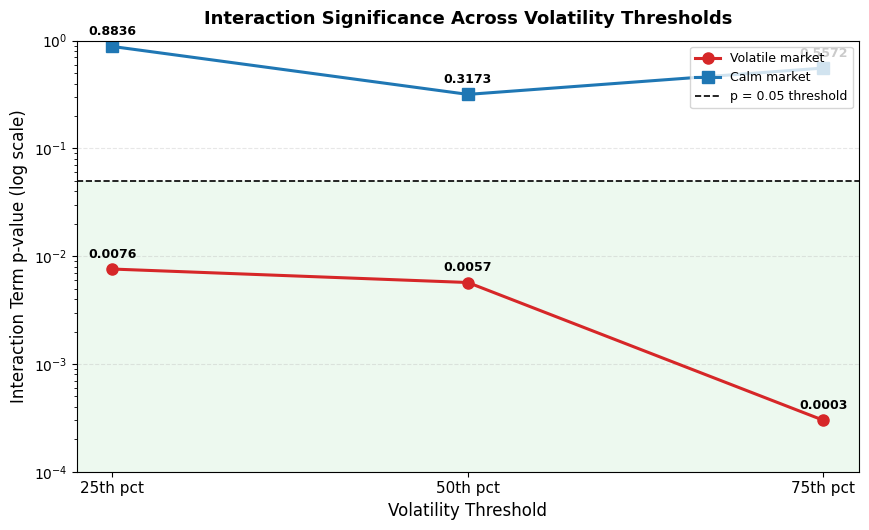

Saved: Fig4_Threshold_Sensitivity.png


In [23]:
# ============================================================
# FIGURE 4 — Robustness: Threshold Sensitivity
# Better version: line plot + log scale
# ============================================================

fig, ax = plt.subplots(figsize=(8.8, 5.4))

threshold_labels = [f"{int(q * 100)}th pct" for q in quantiles]
x = np.arange(len(threshold_labels))

vol_ps = np.array([row['Volatile Interact p'] for _, row in table5a.iterrows()], dtype=float)
calm_ps = np.array([row['Calm I nteract p'] for _, row in table5a.iterrows()], dtype=float)

# ------------------------------------------------------------
# Shade significant region
# ------------------------------------------------------------
ax.axhspan(1e-4, 0.05, color='#d8f3dc', alpha=0.45)

# ------------------------------------------------------------
# Plot lines
# ------------------------------------------------------------
ax.plot(
    x, vol_ps,
    marker='o',
    markersize=8,
    linewidth=2.2,
    color='#d62728',
    label='Volatile market'
)

ax.plot(
    x, calm_ps,
    marker='s',
    markersize=8,
    linewidth=2.2,
    color='#1f77b4',
    label='Calm market'
)

# ------------------------------------------------------------
# Significance threshold
# ------------------------------------------------------------
ax.axhline(
    y=0.05,
    color='black',
    linestyle='--',
    linewidth=1.2,
    label='p = 0.05 threshold'
)

# ------------------------------------------------------------
# Point annotations
# ------------------------------------------------------------
for xi, p in zip(x, vol_ps):
    ax.annotate(
        f'{p:.4f}',
        (xi, p),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

for xi, p in zip(x, calm_ps):
    ax.annotate(
        f'{p:.4f}',
        (xi, p),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

# ------------------------------------------------------------
# Axis formatting
# ------------------------------------------------------------
ax.set_xticks(x)
ax.set_xticklabels(threshold_labels, fontsize=11)

ax.set_yscale('log')
ax.set_ylim(1e-4, 1)

ax.set_xlabel('Volatility Threshold', fontsize=12)
ax.set_ylabel('Interaction Term p-value (log scale)', fontsize=12)

ax.set_title(
    'Interaction Significance Across Volatility Thresholds',
    fontsize=13,
    fontweight='bold',
    pad=12
)

ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.legend(loc='upper right', fontsize=9, frameon=True)

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURES_DIR, "Fig4_Threshold_Sensitivity.png"),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Saved: Fig4_Threshold_Sensitivity.png")

In [19]:
# ============================================================
# SUMMARY
# ============================================================

print("=" * 80)
print("ALL OUTPUTS GENERATED")
print("=" * 80)

print(f"\nTables saved to: {TABLES_DIR}")

for f in sorted(os.listdir(TABLES_DIR)):
    print(f"  {f}")

print(f"\nFigures saved to: {FIGURES_DIR}")

for f in sorted(os.listdir(FIGURES_DIR)):
    print(f"  {f}")

print("""
PLACEMENT GUIDE:

Table 1 + Figure 1  → Methodology Section 3.5 — justifies window choice

Table 2             → Results — primary interaction test

Table 3 + Figure 2  → Results — supplementary overlapping-window test and sign-flipping pattern

Figure 3            → Results — shows interaction term is the most consistently significant variable

Table 5a + Figure 4 → Results — robustness threshold sensitivity

Table 5b            → Results — robustness zero-sentiment exclusion

Table 5c            → Results — robustness volatility definition
""")

ALL OUTPUTS GENERATED

Tables saved to: ..\..\Dissertation_Results\Tables
  07_Interaction_Test
  Table1_Regime_Balance.csv
  Table2_NonOverlap_Results.csv
  Table3_Overlap_Results.csv
  Table4_Prediction_Comparison.csv
  Table5a_Threshold_Sensitivity.csv
  Table5b_Zero_Sentiment.csv
  Table5c_Volatility_Definition.csv

Figures saved to: ..\..\Dissertation_Results\Figures
  07_Interaction_Test
  Fig1_Regime_Balance.png
  Fig2_Interaction_Coefficients.png
  Fig3_PValue_Comparison.png
  Fig4_Threshold_Sensitivity.png

PLACEMENT GUIDE:

Table 1 + Figure 1  → Methodology Section 3.5 — justifies window choice

Table 2             → Results — primary interaction test

Table 3 + Figure 2  → Results — supplementary overlapping-window test and sign-flipping pattern

Figure 3            → Results — shows interaction term is the most consistently significant variable

Table 5a + Figure 4 → Results — robustness threshold sensitivity

Table 5b            → Results — robustness zero-sentiment exclus

Dataset: 578,903 rows, 523 tickers
Date range: 2020-01-31 to 2025-12-30

TABLE 1: Regime Balance Comparison Across Window Configurations
Config    Window      N  Volatile %  Calm %  Independent Tests
1-year      2020  74636        93.9     6.1                  6
1-year      2021  90514        35.4    64.6                  6
1-year      2022 105455        84.6    15.4                  6
1-year      2023 104574        18.3    81.7                  6
1-year      2024 105073        18.1    81.9                  6
1-year      2025  98651        61.4    38.6                  6
2-year 2020-2021 165150        61.9    38.1                  3
2-year 2022-2023 210029        51.6    48.4                  3
2-year 2024-2025 203724        39.1    60.9                  3
3-year 2020-2022 270605        70.7    29.3                  2
3-year 2023-2025 308298        32.0    68.0                  2
Saved: Table1_Regime_Balance.csv

TABLE 2: Non-Overlapping 2-Year Window Results (Primary)
   Window      N

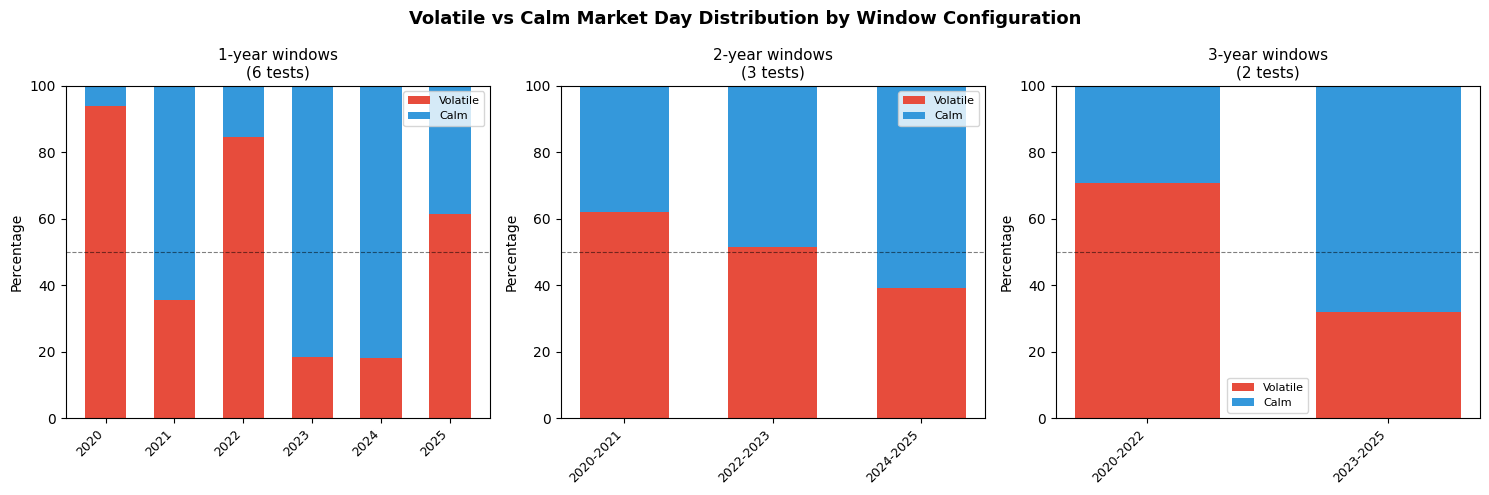

Saved: Fig1_Regime_Balance.png



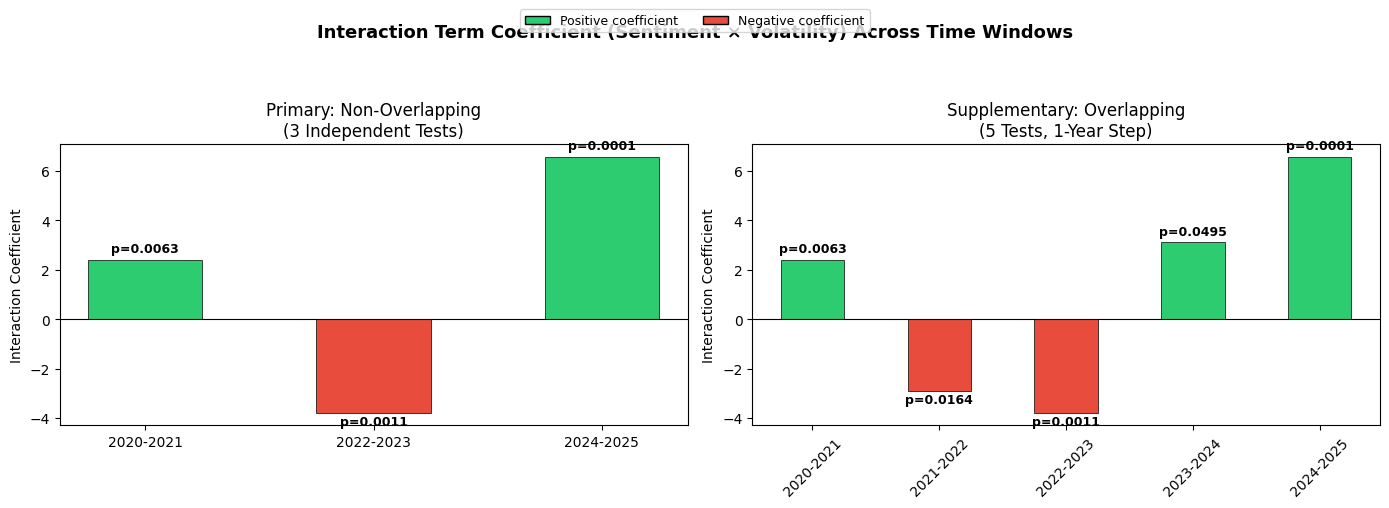

Saved: Fig2_Interaction_Coefficients.png



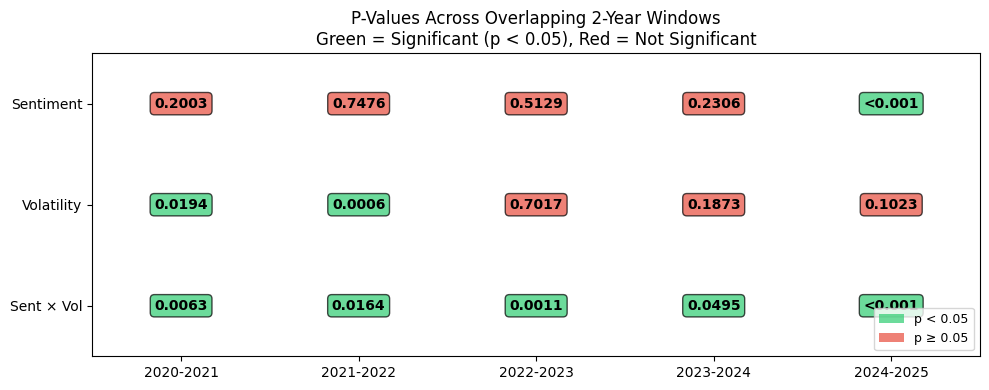

Saved: Fig3_PValue_Comparison.png



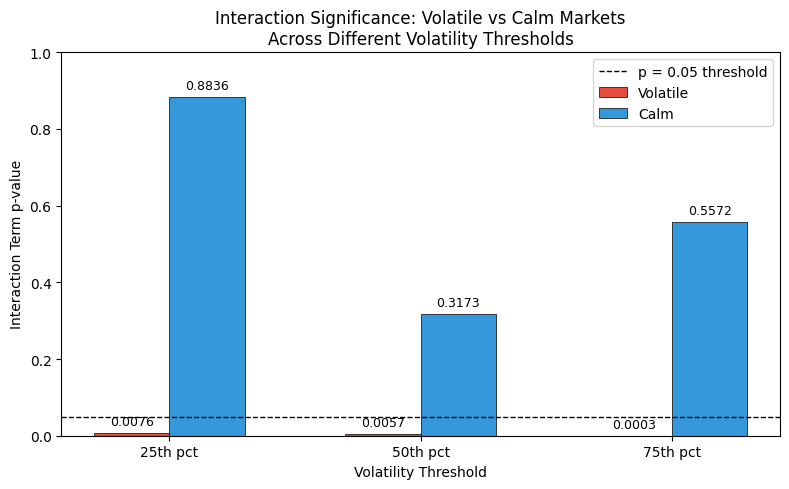

Saved: Fig4_Threshold_Sensitivity.png

ALL OUTPUTS GENERATED

Tables saved to: ..\..\Dissertation_Results\Tables
  07_Interaction_Test
  Table1_Regime_Balance.csv
  Table2_NonOverlap_Results.csv
  Table3_Overlap_Results.csv
  Table4_Prediction_Comparison.csv
  Table5a_Threshold_Sensitivity.csv
  Table5b_Zero_Sentiment.csv
  Table5c_Volatility_Definition.csv

Figures saved to: ..\..\Dissertation_Results\Figures
  07_Interaction_Test
  Fig1_Regime_Balance.png
  Fig2_Interaction_Coefficients.png
  Fig3_PValue_Comparison.png
  Fig4_Threshold_Sensitivity.png

PLACEMENT GUIDE:
  Table 1 + Figure 1  → Methodology (Section 3.5) — justifies window choice
  Table 2             → Results — primary interaction test
  Table 3 + Figure 2  → Results — supplementary + sign-flipping
  Figure 3            → Results — interaction is only consistent variable
  Table 5a + Figure 4 → Results — robustness threshold sensitivity
  Table 5b            → Results — robustness zero-sentiment
  Table 5c            

In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# SETUP — adjust these paths to match your folder structure
# ============================================================
DATA_PATH = r"..\..\Data\Main\modelling_dataset.csv"
OUTPUT_DIR = r"..\..\Dissertation_Results"
TABLES_DIR = os.path.join(OUTPUT_DIR, "Tables")
FIGURES_DIR = os.path.join(OUTPUT_DIR, "Figures")
os.makedirs(TABLES_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
model_df = df.dropna(subset=['volatility_20d', 'next_day_return']).copy()
model_df = model_df.sort_values(['ticker', 'date']).reset_index(drop=True)
features = ['sentiment', 'volatility_20d', 'sent_x_vol']

print(f"Dataset: {model_df.shape[0]:,} rows, {model_df['ticker'].nunique()} tickers")
print(f"Date range: {model_df['date'].min().date()} to {model_df['date'].max().date()}\n")

# ============================================================
# HELPER FUNCTIONS
# ============================================================
def sig_stars(p):
    if p < 0.01: return "***"
    elif p < 0.05: return "**"
    elif p < 0.1: return "*"
    else: return "ns"

def run_logit(data):
    """Run logistic regression and return params and pvalues."""
    X = sm.add_constant(data[features])
    y = data['target']
    result = sm.Logit(y, X).fit(disp=0)
    return result

def get_window_data(start, end):
    """Filter model_df to a date range and drop NaN features."""
    return model_df[(model_df['date'] >= start) & (model_df['date'] <= end)].dropna(subset=features)


# ============================================================
# TABLE 1 — Regime Balance Comparison (METHODOLOGY)
# ============================================================
print("=" * 80)
print("TABLE 1: Regime Balance Comparison Across Window Configurations")
print("=" * 80)

window_configs = {
    '1-year': [
        ('2020', '2020-01-01', '2020-12-31'),
        ('2021', '2021-01-01', '2021-12-31'),
        ('2022', '2022-01-01', '2022-12-31'),
        ('2023', '2023-01-01', '2023-12-31'),
        ('2024', '2024-01-01', '2024-12-31'),
        ('2025', '2025-01-01', '2025-12-31'),
    ],
    '2-year': [
        ('2020-2021', '2020-01-01', '2021-12-31'),
        ('2022-2023', '2022-01-01', '2023-12-31'),
        ('2024-2025', '2024-01-01', '2025-12-31'),
    ],
    '3-year': [
        ('2020-2022', '2020-01-01', '2022-12-31'),
        ('2023-2025', '2023-01-01', '2025-12-31'),
    ],
}

table1_rows = []
for config_name, windows in window_configs.items():
    for name, start, end in windows:
        subset = get_window_data(start, end)
        vol_pct = (subset['volatile_market'] == 1).mean() * 100
        table1_rows.append({
            'Config': config_name,
            'Window': name,
            'N': len(subset),
            'Volatile %': round(vol_pct, 1),
            'Calm %': round(100 - vol_pct, 1),
            'Independent Tests': len(windows)
        })

table1 = pd.DataFrame(table1_rows)
print(table1.to_string(index=False))
table1.to_csv(os.path.join(TABLES_DIR, "Table1_Regime_Balance.csv"), index=False)
print("Saved: Table1_Regime_Balance.csv\n")


# ============================================================
# TABLE 2 — Non-Overlapping 2-Year Windows (RESULTS)
# ============================================================
print("=" * 80)
print("TABLE 2: Non-Overlapping 2-Year Window Results (Primary)")
print("=" * 80)

non_overlap_windows = [
    ('2020-2021', '2020-01-01', '2021-12-31'),
    ('2022-2023', '2022-01-01', '2023-12-31'),
    ('2024-2025', '2024-01-01', '2025-12-31'),
]

table2_rows = []
for name, start, end in non_overlap_windows:
    subset = get_window_data(start, end)
    r = run_logit(subset)
    table2_rows.append({
        'Window': name,
        'N': len(subset),
        'Sent coef': round(r.params['sentiment'], 4),
        'Sent p': round(r.pvalues['sentiment'], 4),
        'Sent sig': sig_stars(r.pvalues['sentiment']),
        'Vol coef': round(r.params['volatility_20d'], 4),
        'Vol p': round(r.pvalues['volatility_20d'], 4),
        'Vol sig': sig_stars(r.pvalues['volatility_20d']),
        'Interact coef': round(r.params['sent_x_vol'], 4),
        'Interact p': round(r.pvalues['sent_x_vol'], 4),
        'Interact sig': sig_stars(r.pvalues['sent_x_vol']),
    })

table2 = pd.DataFrame(table2_rows)
print(table2.to_string(index=False))
table2.to_csv(os.path.join(TABLES_DIR, "Table2_NonOverlap_Results.csv"), index=False)
print("Saved: Table2_NonOverlap_Results.csv\n")


# ============================================================
# TABLE 3 — Overlapping 2-Year Windows (RESULTS)
# ============================================================
print("=" * 80)
print("TABLE 3: Overlapping 2-Year Window Results (Supplementary)")
print("=" * 80)

overlap_windows = [
    ('2020-2021', '2020-01-01', '2021-12-31'),
    ('2021-2022', '2021-01-01', '2022-12-31'),
    ('2022-2023', '2022-01-01', '2023-12-31'),
    ('2023-2024', '2023-01-01', '2024-12-31'),
    ('2024-2025', '2024-01-01', '2025-12-31'),
]

table3_rows = []
for name, start, end in overlap_windows:
    subset = get_window_data(start, end)
    r = run_logit(subset)
    table3_rows.append({
        'Window': name,
        'N': len(subset),
        'Interact coef': round(r.params['sent_x_vol'], 4),
        'Interact p': round(r.pvalues['sent_x_vol'], 4),
        'Significance': sig_stars(r.pvalues['sent_x_vol']),
        'Direction': 'Positive' if r.params['sent_x_vol'] > 0 else 'Negative',
    })

table3 = pd.DataFrame(table3_rows)
print(table3.to_string(index=False))
table3.to_csv(os.path.join(TABLES_DIR, "Table3_Overlap_Results.csv"), index=False)
print("Saved: Table3_Overlap_Results.csv\n")


# ============================================================
# FULL PERIOD RESULT (RESULTS — reference row)
# ============================================================
print("=" * 80)
print("FULL PERIOD: Interaction Term (Reference)")
print("=" * 80)

full_data = model_df.dropna(subset=features)
r_full = run_logit(full_data)
print(f"N = {len(full_data):,}")
print(f"Sentiment:   coef={r_full.params['sentiment']:.4f}, p={r_full.pvalues['sentiment']:.4f} {sig_stars(r_full.pvalues['sentiment'])}")
print(f"Volatility:  coef={r_full.params['volatility_20d']:.4f}, p={r_full.pvalues['volatility_20d']:.4f} {sig_stars(r_full.pvalues['volatility_20d'])}")
print(f"Interaction: coef={r_full.params['sent_x_vol']:.4f}, p={r_full.pvalues['sent_x_vol']:.4f} {sig_stars(r_full.pvalues['sent_x_vol'])}")
print()


# ============================================================
# TABLE 5a — Robustness: Volatility Threshold Sensitivity (RESULTS)
# ============================================================
print("=" * 80)
print("TABLE 5a: Robustness — Volatility Threshold Sensitivity")
print("=" * 80)

quantiles = [0.25, 0.50, 0.75]
table5a_rows = []
for q in quantiles:
    cutoff = model_df['market_vol'].quantile(q)
    vol_data = model_df[model_df['market_vol'] > cutoff].dropna(subset=features)
    calm_data = model_df[model_df['market_vol'] <= cutoff].dropna(subset=features)
    
    r_vol = run_logit(vol_data)
    r_calm = run_logit(calm_data)
    
    table5a_rows.append({
        'Threshold': f"{int(q*100)}th percentile",
        'Cutoff': round(cutoff, 4),
        'Volatile N': len(vol_data),
        'Volatile Interact p': round(r_vol.pvalues['sent_x_vol'], 4),
        'Volatile sig': sig_stars(r_vol.pvalues['sent_x_vol']),
        'Calm N': len(calm_data),
        'Calm Interact p': round(r_calm.pvalues['sent_x_vol'], 4),
        'Calm sig': sig_stars(r_calm.pvalues['sent_x_vol']),
    })

table5a = pd.DataFrame(table5a_rows)
print(table5a.to_string(index=False))
table5a.to_csv(os.path.join(TABLES_DIR, "Table5a_Threshold_Sensitivity.csv"), index=False)
print("Saved: Table5a_Threshold_Sensitivity.csv\n")


# ============================================================
# TABLE 5b — Robustness: Zero-Sentiment Exclusion (RESULTS)
# ============================================================
print("=" * 80)
print("TABLE 5b: Robustness — Zero-Sentiment Exclusion")
print("=" * 80)

nonzero_data = model_df[model_df['sentiment'] != 0].dropna(subset=features)

table5b_rows = []
for name, start, end in non_overlap_windows:
    with_z = full_data[(full_data['date'] >= start) & (full_data['date'] <= end)]
    without_z = nonzero_data[(nonzero_data['date'] >= start) & (nonzero_data['date'] <= end)]
    
    r_wz = run_logit(with_z)
    r_woz = run_logit(without_z)
    
    table5b_rows.append({
        'Window': name,
        'With zeros N': len(with_z),
        'With zeros Interact p': round(r_wz.pvalues['sent_x_vol'], 4),
        'With zeros sig': sig_stars(r_wz.pvalues['sent_x_vol']),
        'Without zeros N': len(without_z),
        'Without zeros Interact p': round(r_woz.pvalues['sent_x_vol'], 4),
        'Without zeros sig': sig_stars(r_woz.pvalues['sent_x_vol']),
    })

table5b = pd.DataFrame(table5b_rows)
print(table5b.to_string(index=False))
table5b.to_csv(os.path.join(TABLES_DIR, "Table5b_Zero_Sentiment.csv"), index=False)
print("Saved: Table5b_Zero_Sentiment.csv\n")


# ============================================================
# TABLE 5c — Robustness: Volatility Definition (RESULTS)
# ============================================================
print("=" * 80)
print("TABLE 5c: Robustness — Per-Stock vs Market-Wide Volatility")
print("=" * 80)

model_df_copy = model_df.copy()
model_df_copy['stock_vol_median'] = model_df_copy.groupby('ticker')['volatility_20d'].transform('median')
model_df_copy['stock_volatile'] = (model_df_copy['volatility_20d'] > model_df_copy['stock_vol_median']).astype(int)

vol_tests = [
    ('Stock-level volatile', model_df_copy[model_df_copy['stock_volatile'] == 1].dropna(subset=features)),
    ('Stock-level calm', model_df_copy[model_df_copy['stock_volatile'] == 0].dropna(subset=features)),
    ('Market-wide volatile', model_df[model_df['volatile_market'] == 1].dropna(subset=features)),
    ('Market-wide calm', model_df[model_df['volatile_market'] == 0].dropna(subset=features)),
]

table5c_rows = []
for name, data in vol_tests:
    r = run_logit(data)
    table5c_rows.append({
        'Regime': name,
        'N': len(data),
        'Interact coef': round(r.params['sent_x_vol'], 4),
        'Interact p': round(r.pvalues['sent_x_vol'], 4),
        'Significance': sig_stars(r.pvalues['sent_x_vol']),
    })

table5c = pd.DataFrame(table5c_rows)
print(table5c.to_string(index=False))
table5c.to_csv(os.path.join(TABLES_DIR, "Table5c_Volatility_Definition.csv"), index=False)
print("Saved: Table5c_Volatility_Definition.csv\n")


# ============================================================
# FIGURE 1 — Regime Balance Visual (METHODOLOGY)
# Shows WHY 2-year windows were chosen
# ============================================================
print("=" * 80)
print("GENERATING FIGURES...")
print("=" * 80)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Volatile vs Calm Market Day Distribution by Window Configuration', fontsize=13, fontweight='bold')

for ax, (config_name, windows) in zip(axes, window_configs.items()):
    names = [w[0] for w in windows]
    subset_data = [get_window_data(w[1], w[2]) for w in windows]
    vol_pcts = [(s['volatile_market'] == 1).mean() * 100 for s in subset_data]
    calm_pcts = [100 - v for v in vol_pcts]
    
    x = np.arange(len(names))
    ax.bar(x, vol_pcts, color='#e74c3c', label='Volatile', width=0.6)
    ax.bar(x, calm_pcts, bottom=vol_pcts, color='#3498db', label='Calm', width=0.6)
    ax.axhline(y=50, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Percentage')
    ax.set_title(f'{config_name} windows\n({len(windows)} tests)', fontsize=11)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "Fig1_Regime_Balance.png"), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: Fig1_Regime_Balance.png\n")


# ============================================================
# FIGURE 2 — Interaction Coefficients: Non-Overlapping + Overlapping
# Shows sign-flipping pattern (RESULTS)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Interaction Term Coefficient (Sentiment × Volatility) Across Time Windows', fontsize=13, fontweight='bold')

# Non-overlapping
coefs_no = [r['Interact coef'] for _, r in table2.iterrows()]
pvals_no = [r['Interact p'] for _, r in table2.iterrows()]
colors_no = ['#2ecc71' if c > 0 else '#e74c3c' for c in coefs_no]

axes[0].bar(table2['Window'], coefs_no, color=colors_no, edgecolor='black', linewidth=0.5, width=0.5)
axes[0].axhline(y=0, color='black', linewidth=0.8)
axes[0].set_ylabel('Interaction Coefficient')
axes[0].set_title('Primary: Non-Overlapping\n(3 Independent Tests)')
for i, (c, p) in enumerate(zip(coefs_no, pvals_no)):
    y_pos = c + 0.3 if c > 0 else c - 0.5
    axes[0].text(i, y_pos, f'p={p:.4f}', ha='center', fontsize=9, fontweight='bold')

# Overlapping
coefs_o = [r['Interact coef'] for _, r in table3.iterrows()]
pvals_o = [r['Interact p'] for _, r in table3.iterrows()]
colors_o = ['#2ecc71' if c > 0 else '#e74c3c' for c in coefs_o]

axes[1].bar(table3['Window'], coefs_o, color=colors_o, edgecolor='black', linewidth=0.5, width=0.5)
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].set_ylabel('Interaction Coefficient')
axes[1].set_title('Supplementary: Overlapping\n(5 Tests, 1-Year Step)')
axes[1].tick_params(axis='x', rotation=45)
for i, (c, p) in enumerate(zip(coefs_o, pvals_o)):
    y_pos = c + 0.3 if c > 0 else c - 0.5
    axes[1].text(i, y_pos, f'p={p:.4f}', ha='center', fontsize=9, fontweight='bold')

legend_items = [
    mpatches.Patch(facecolor='#2ecc71', edgecolor='black', label='Positive coefficient'),
    mpatches.Patch(facecolor='#e74c3c', edgecolor='black', label='Negative coefficient')
]
fig.legend(handles=legend_items, loc='upper center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(os.path.join(FIGURES_DIR, "Fig2_Interaction_Coefficients.png"), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: Fig2_Interaction_Coefficients.png\n")


# ============================================================
# FIGURE 3 — P-Value Comparison Across Overlapping Windows
# Shows interaction is the ONLY consistently significant variable (RESULTS)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 4))

var_labels = ['Sentiment', 'Volatility', 'Sent × Vol']
var_keys = ['sentiment', 'volatility_20d', 'sent_x_vol']
window_names = [name for name, _, _ in overlap_windows]

for row_idx, (var_key, var_label) in enumerate(zip(var_keys, var_labels)):
    y_pos = 2.0 - row_idx
    for i, (name, start, end) in enumerate(overlap_windows):
        subset = get_window_data(start, end)
        r = run_logit(subset)
        p = r.pvalues[var_key]
        
        box_color = '#2ecc71' if p < 0.05 else '#e74c3c'
        p_label = f'{p:.4f}' if p > 0.0001 else '<0.001'
        ax.text(i, y_pos, p_label, ha='center', va='center', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=box_color, alpha=0.7))

ax.set_yticks([0.0, 1.0, 2.0])
ax.set_yticklabels(list(reversed(var_labels)))
ax.set_xticks(range(len(window_names)))
ax.set_xticklabels(window_names)
ax.set_xlim(-0.5, len(window_names) - 0.5)
ax.set_ylim(-0.5, 2.5)
ax.set_title('P-Values Across Overlapping 2-Year Windows\nGreen = Significant (p < 0.05), Red = Not Significant', fontsize=12)

legend_items = [
    mpatches.Patch(facecolor='#2ecc71', alpha=0.7, label='p < 0.05'),
    mpatches.Patch(facecolor='#e74c3c', alpha=0.7, label='p ≥ 0.05')
]
ax.legend(handles=legend_items, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "Fig3_PValue_Comparison.png"), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: Fig3_PValue_Comparison.png\n")


# ============================================================
# FIGURE 4 — Robustness: Threshold Sensitivity (RESULTS)
# Shows interaction significant in volatile at ALL thresholds, never in calm
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))

threshold_labels = [f"{int(q*100)}th pct" for q in quantiles]
vol_ps = [row['Volatile Interact p'] for _, row in table5a.iterrows()]
calm_ps = [row['Calm Interact p'] for _, row in table5a.iterrows()]

x = np.arange(len(threshold_labels))
width = 0.3

bars_vol = ax.bar(x - width/2, vol_ps, width, color='#e74c3c', label='Volatile', edgecolor='black', linewidth=0.5)
bars_calm = ax.bar(x + width/2, calm_ps, width, color='#3498db', label='Calm', edgecolor='black', linewidth=0.5)

ax.axhline(y=0.05, color='black', linestyle='--', linewidth=1, label='p = 0.05 threshold')
ax.set_xticks(x)
ax.set_xticklabels(threshold_labels)
ax.set_xlabel('Volatility Threshold')
ax.set_ylabel('Interaction Term p-value')
ax.set_title('Interaction Significance: Volatile vs Calm Markets\nAcross Different Volatility Thresholds')
ax.legend()
ax.set_ylim(0, 1.0)

for bar in bars_vol:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.02, f'{h:.4f}', ha='center', fontsize=9)
for bar in bars_calm:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.02, f'{h:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "Fig4_Threshold_Sensitivity.png"), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: Fig4_Threshold_Sensitivity.png\n")


# ============================================================
# SUMMARY
# ============================================================
print("=" * 80)
print("ALL OUTPUTS GENERATED")
print("=" * 80)
print(f"\nTables saved to: {TABLES_DIR}")
for f in sorted(os.listdir(TABLES_DIR)):
    print(f"  {f}")
print(f"\nFigures saved to: {FIGURES_DIR}")
for f in sorted(os.listdir(FIGURES_DIR)):
    print(f"  {f}")
print("""
PLACEMENT GUIDE:
  Table 1 + Figure 1  → Methodology (Section 3.5) — justifies window choice
  Table 2             → Results — primary interaction test
  Table 3 + Figure 2  → Results — supplementary + sign-flipping
  Figure 3            → Results — interaction is only consistent variable
  Table 5a + Figure 4 → Results — robustness threshold sensitivity
  Table 5b            → Results — robustness zero-sentiment
  Table 5c            → Results — robustness volatility definition
""")